In [1]:
# -----------------------------
# 0) Imports + Settings
# -----------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

pd.set_option("display.max_columns", 200)
np.random.seed(42)


In [2]:
# -----------------------------
# 1) Load Data
# -----------------------------
# Update this path to your CSV
DATA_PATH = "../../data/processed/NOAA/NOAA_Global_Bleaching_Cleaned.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df


(41361, 48)


/var/folders/25/4sydytjj5kx7w08vfts5w61r0000gn/T/ipykernel_84207/3220284412.py:7: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,Unnamed: 0,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,0,27.2616,-78.3844,Atlantic,796.97,Sheltered,0.1689,38.49,nd,nd,nd,75,302.25,303.85,299.37,291.98,304.83,2.49,0.94,1,0,-5.23,3.06,9,5.6,27,6,12.05,3.03,15.31,2.3,0.87,2.49,-11,1.84,-3.6,1,0.69,3,0,1.57,0.45,3.23,0.11,8/15/1998,60% (GCRMN 2000),60% (GCRMN 2000),Bleaching percent averaged from code: Severe (...
1,1,27.2649,-78.4000,Atlantic,450.45,Sheltered,0.1689,38.49,nd,nd,nd,75,300.83,301.69,299.37,291.98,304.83,2.49,-0.34,1,0,-5.23,3.06,9,5.6,27,6,4.28,3.03,15.31,2.3,-1.29,2.49,-11,1.84,-3.6,1,0.69,3,0,1.57,0.45,3.23,0.11,9/15/1998,great amount of coral that was bleached white;...,great amount of coral that was bleached white;...,Bleaching percent averaged from code: Severe (...
2,2,26.5775,-76.9590,Atlantic,1653.69,Exposed,0.0937,53.11,4.2,nd,nd,4.13,302.11,303.7,299.28,294.52,304.45,2.14,1.37,1,0,-3.68,2.57,1,4.18,20,4,0,2.17,13.26,1.36,1.37,2.14,-7.8,2.11,-3.04,1,0.52,2,0,0,0.39,2.52,0.1,8/15/1999,nd,nd,nd
3,3,26.5403,-76.9462,Atlantic,1055.21,Exposed,0.0394,53.11,5.7,nd,nd,7.78,302.17,303.18,299.3,294.79,305.08,2.14,0.8,1,0,-3.66,3.59,5,4.01,19,4,1.08,2.26,12.11,1.46,0.8,2.14,-7.58,2.7,-3.07,1,0.64,4,0,0,0.49,5.36,0.1,8/15/1999,nd,nd,nd
4,4,26.5973,-76.9764,Atlantic,2185.56,Exposed,0.0399,61.47,3.1,nd,nd,8.26,302.11,303.7,299.28,294.52,304.45,2.14,1.37,1,0,-3.68,2.57,1,4.18,20,4,0,2.17,13.26,1.36,1.37,2.14,-7.8,2.11,-3.04,1,0.52,2,0,0,0.39,2.52,0.1,8/15/1999,nd,nd,nd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41356,41356,-6.2848,39.1764,Indian,318.46,Sheltered,0.0659,41.99,5,53.61,nd,nd,299.77,302.48,300.49,295.94,306.14,1.56,0.96,0.78,0,-3.45,4.03,18,3.85,18,5,9.67,2.27,14.3,1.66,0.34,1.56,-6.19,4,-1.64,6,1.74,8,2,6.96,1.53,10.82,0.67,4/30/2016,nd,Nyawira,nd
41357,41357,-6.2848,39.1764,Indian,318.46,Sheltered,0.0659,41.99,5,58.25,nd,nd,299.77,302.48,300.49,295.94,306.14,1.56,0.96,0.78,0,-3.45,4.03,18,3.85,18,5,9.67,2.27,14.3,1.66,0.34,1.56,-6.19,4,-1.64,6,1.74,8,2,6.96,1.53,10.82,0.67,4/30/2016,nd,C. Muhando,nd
41358,41358,-6.2772,39.1744,Indian,226.96,Sheltered,0.0659,41.99,5,50.67,nd,nd,299.77,302.48,300.49,295.94,306.14,1.56,0.96,0.78,0,-3.45,4.03,18,3.85,18,5,9.67,2.27,14.3,1.66,0.34,1.56,-6.19,4,-1.64,6,1.74,8,2,6.96,1.53,10.82,0.67,4/30/2016,nd,Ussi,nd
41359,41359,-6.1562,39.1223,Indian,683.35,Sheltered,0.0602,42.06,3,55,nd,nd,299.79,302.26,300.52,295.48,305.29,1.54,0.8,0.79,0,-3.08,3.23,12,3.63,16,4,8.04,2.36,15.12,1.66,0.14,1.54,-6.62,3.17,-1.58,6,2.06,9,2,7.84,1.67,10,0.72,4/29/2016,nd,Nyawira,nd


In [3]:
# -----------------------------
# 2) Basic cleaning
# -----------------------------
# Strip whitespace from column names
df.columns = [c.strip() for c in df.columns]

# Parse Date if present
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Quick glance at missingness
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)


Unnamed: 0                          0.0
Latitude_Degrees                    0.0
SSTA_FrequencyMean                  0.0
SSTA_DHW                            0.0
SSTA_DHW_Standard_Deviation         0.0
SSTA_DHWMax                         0.0
SSTA_DHWMean                        0.0
TSA                                 0.0
TSA_Standard_Deviation              0.0
TSA_Minimum                         0.0
TSA_Maximum                         0.0
TSA_Mean                            0.0
TSA_Frequency                       0.0
TSA_Frequency_Standard_Deviation    0.0
TSA_FrequencyMax                    0.0
TSA_FrequencyMean                   0.0
TSA_DHW                             0.0
TSA_DHW_Standard_Deviation          0.0
TSA_DHWMax                          0.0
TSA_DHWMean                         0.0
dtype: float64

In [4]:
# -----------------------------
# 3) Define Targets + Features
# -----------------------------
# Primary regression target
TARGET_REG = "Percent_Bleaching"

# Optional classification target
TARGET_CLS = "Bleaching_Level"

# Columns you typically should NOT use as predictors (free-text + comments)
drop_text = [c for c in df.columns if "Comments" in c] + ["Site_Comments", "Sample_Comments", "Bleaching_Comments"]
drop_text = [c for c in drop_text if c in df.columns]

# You may or may not want to drop Date (keep it if you do time-based analyses)
# For baseline modeling, we’ll turn Date into year/month features (optional).
use_date_features = "Date" in df.columns

# Keep a copy
data = df.copy()

# Ensure target is numeric so it remains in corr
if "Percent Bleaching" in data.columns and "Percent_Bleaching" not in data.columns:
    data = data.rename(columns={"Percent Bleaching": "Percent_Bleaching"})
if "Percent_Bleaching" in data.columns:
    data["Percent_Bleaching"] = pd.to_numeric(data["Percent_Bleaching"], errors="coerce")

# Create simple date features (optional)
if use_date_features:
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month

# Candidate predictors (exclude targets and text)
exclude = set([TARGET_REG, TARGET_CLS, "Date"]) | set(drop_text)
feature_cols = [c for c in data.columns if c not in exclude]

# If you want to remove raw lat/long from non-spatial models, uncomment:
# Normalize mixed-type feature columns to avoid OneHotEncoder errors
for c in feature_cols:
    if data[c].dtype == "object":
        as_num = pd.to_numeric(data[c], errors="coerce")
        if as_num.notna().mean() >= 0.9:
            data[c] = as_num
        else:
            data[c] = data[c].astype("string")

# feature_cols = [c for c in feature_cols if c not in ["Latitude_Degrees", "Longitude_Degrees"]]

print("Num features:", len(feature_cols))
feature_cols[:20]


Num features: 44


['Unnamed: 0',
 'Latitude_Degrees',
 'Longitude_Degrees',
 'Ocean_Name',
 'Distance_to_Shore',
 'Exposure',
 'Turbidity',
 'Cyclone_Frequency',
 'Depth_m',
 'Percent_Cover',
 'ClimSST',
 'Temperature_Kelvin',
 'Temperature_Mean',
 'Temperature_Minimum',
 'Temperature_Maximum',
 'Temperature_Kelvin_Standard_Deviation',
 'SSTA',
 'SSTA_Standard_Deviation',
 'SSTA_Mean',
 'SSTA_Minimum']

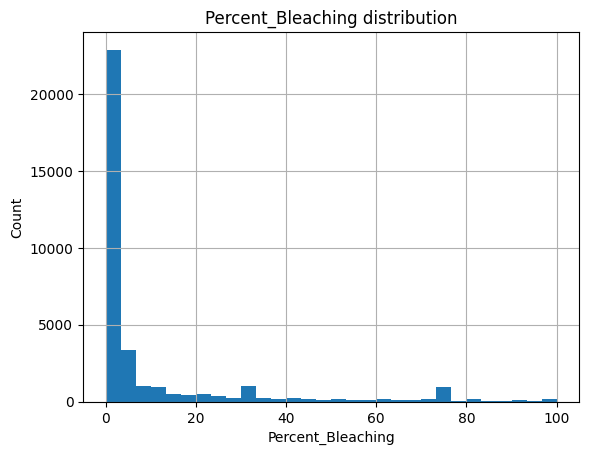

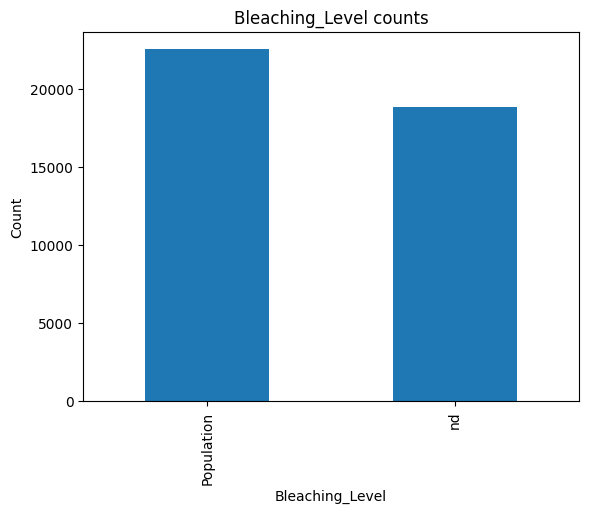

In [5]:
# -----------------------------
# 4) Quick EDA
# -----------------------------
# Distribution of Percent_Bleaching
if TARGET_REG in data.columns:
    plt.figure()
    data[TARGET_REG].dropna().hist(bins=30)
    plt.title("Percent_Bleaching distribution")
    plt.xlabel("Percent_Bleaching")
    plt.ylabel("Count")
    plt.show()

# If Bleaching_Level exists, show counts
if TARGET_CLS in data.columns:
    plt.figure()
    data[TARGET_CLS].astype("category").value_counts(dropna=False).plot(kind="bar")
    plt.title("Bleaching_Level counts")
    plt.xlabel("Bleaching_Level")
    plt.ylabel("Count")
    plt.show()


In [6]:
# -----------------------------
# 5) Correlation (numeric only) — helps detect redundancy
# -----------------------------
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(data[c])]
corr = data[numeric_cols + ([TARGET_REG] if TARGET_REG in data.columns else [])].corr(numeric_only=True)

# Show top correlations with target
if TARGET_REG in data.columns and TARGET_REG in corr.columns:
    target_corr = corr[TARGET_REG].drop(TARGET_REG).sort_values(key=lambda s: s.abs(), ascending=False)
    target_corr.head(15)
else:
    print("Target not found for correlation analysis.")

target_corr


SSTA_DHW                                 0.272392
TSA_DHW                                  0.272091
Year                                    -0.214274
SSTA_Frequency                           0.188832
Depth_m                                  0.165545
TSA_Frequency                            0.162356
Longitude_Degrees                       -0.144262
TSA                                      0.142379
SSTA_Standard_Deviation                  0.137434
SSTA                                     0.119348
Temperature_Kelvin                       0.107627
TSA_Frequency_Standard_Deviation        -0.101926
SSTA_Frequency_Standard_Deviation       -0.092733
TSA_FrequencyMax                        -0.085899
SSTA_FrequencyMax                       -0.078374
TSA_Mean                                -0.072845
SSTA_FrequencyMean                      -0.072664
Temperature_Mean                        -0.064810
SSTA_DHWMax                             -0.051755
Latitude_Degrees                         0.051453


In [7]:
# -----------------------------
# 6) Train/Test Split (Regression)
# -----------------------------
# Keep only rows with target for regression
reg_df = data.dropna(subset=[TARGET_REG]).copy()

X = reg_df[feature_cols]
y = reg_df[TARGET_REG]

# Identify categorical vs numeric predictors
cat_cols = [c for c in feature_cols if (not pd.api.types.is_numeric_dtype(reg_df[c]))]
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test)

(27612, 6903)

In [8]:
# -----------------------------
# 7) Preprocessing Pipeline
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_sparse = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_sparse = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer_sparse, cat_cols)
    ],
    remainder="drop"
)

preprocess_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer_dense, cat_cols)
    ],
    remainder="drop",
    sparse_threshold=0.0  # force dense output for HistGradientBoosting
)

# Default preprocessor used by sparse-compatible models
preprocess = preprocess_sparse

preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [9]:
# Normalize mixed-type feature columns
for c in feature_cols:
    if data[c].dtype == "object":
        as_num = pd.to_numeric(data[c], errors="coerce")
        if as_num.notna().mean() >= 0.9:
            data[c] = as_num
        else:
            data[c] = data[c].astype("string")

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    # "RandomForestRegressor": RandomForestRegressor(
    #     n_estimators=400,
    #     random_state=42,
    #     n_jobs=-1,
    #     min_samples_leaf=2
    # ),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

fitted_models = {}
results = []

for name, model in models.items():
    # HistGradientBoosting requires dense input; others can use sparse
    preprocess_for_model = preprocess_dense if name == "HistGradientBoosting" else preprocess_sparse

    pipe = Pipeline(steps=[
        ("preprocess", preprocess_for_model),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    # Save the fitted pipeline
    fitted_models[name] = pipe

    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, pred)

    results.append((name, mae, rmse, r2))

res_df = (
    pd.DataFrame(results, columns=["model", "MAE", "RMSE", "R2"])
    .sort_values("RMSE")
)


,model,MAE,RMSE,R2
2,HistGradientBoosting,4.370573,9.039189,0.798615
0,LinearRegression,9.720017,15.714454,0.391351
1,Ridge,9.763981,15.728750,0.390243


In [12]:
res_df

,model,MAE,RMSE,R2
2,HistGradientBoosting,4.370573,9.039189,0.798615
0,LinearRegression,9.720017,15.714454,0.391351
1,Ridge,9.763981,15.728750,0.390243


In [19]:
param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [None, 5, 10],
    "model__max_iter": [200, 400, 800]
}

preprocess = preprocess_dense.set_params(sparse_threshold=0.0)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", HistGradientBoostingRegressor(random_state=42))
], verbose=True
)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)


[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.6s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.9s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.0s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.1s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.2s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.2s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.1s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   1.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=  25.0s
[Pipeline] ............. (step 2 of 2) Processing model, total=  25.1s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.3s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.3s
[Pipeline] ............. (step 2 of 2) Processing model, total=  25.4s
[Pipeline] ........ (step 1 of 2) Processing preprocess, total=   0.3s
[Pipel

KeyboardInterrupt: 